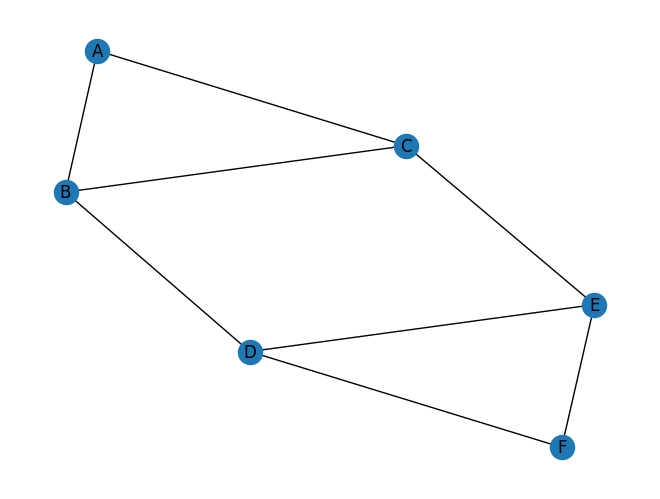

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

vertices = ['A', 'B', 'C', 'D', 'E', 'F']

edges = [
    ('A','B'), ('A','C'), ('B','C'), ('B','D'),
    ('C','E'), ('D','E'), ('D','F'), ('E','F')
]

G = nx.Graph() # Initialize G as a graph object
G.add_nodes_from(vertices)
G.add_edges_from(edges)

nx.draw(G, with_labels=True)
plt.show()

In [20]:
#(a) Adjacency Matrix

adj_matrix = nx.adjacency_matrix(G).toarray()
print("Adjacency Matrix: ")
print(pd.DataFrame(adj_matrix, index=vertices, columns=vertices))

Adjacency Matrix: 
   A  B  C  D  E  F
A  0  1  1  0  0  0
B  1  0  1  1  0  0
C  1  1  0  0  1  0
D  0  1  0  0  1  1
E  0  0  1  1  0  1
F  0  0  0  1  1  0


In [23]:
# (b)Incidence matrix
inc_matrix = nx.incidence_matrix(G, oriented=False).toarray().astype(int)
edge_names = [f"e{idx+1}" for idx in range(len(edges))]

print("Incidence Matrix:")
print(pd.DataFrame(inc_matrix, index=vertices, columns=edge_names))


Incidence Matrix:
   e1  e2  e3  e4  e5  e6  e7  e8
A   1   1   0   0   0   0   0   0
B   1   0   1   1   0   0   0   0
C   0   1   1   0   1   0   0   0
D   0   0   0   1   0   1   1   0
E   0   0   0   0   1   1   0   1
F   0   0   0   0   0   0   1   1


In [28]:
# (c) Adjacency List

print("Adjacency List: ")
for node in G.nodes():
    print(f"{node}: {list(G.neighbors(node))}")


Adjacency List: 
A: ['B', 'C']
B: ['A', 'C', 'D']
C: ['A', 'B', 'E']
D: ['B', 'E', 'F']
E: ['C', 'D', 'F']
F: ['D', 'E']


Planar Graph Analysis
a) Visualize the graph using Python and determine whether the graph is planar.
b) Use Euler’s planar graph theorem ( V - E + F = 2 ) to verify whether the graph satisfies the planar condition.
c) If the graph is planar, compute the number of regions in a planar embedding.
d) Write a Python function that checks whether the inequality ( E <= 3V - 6 ) holds and interpret the result.


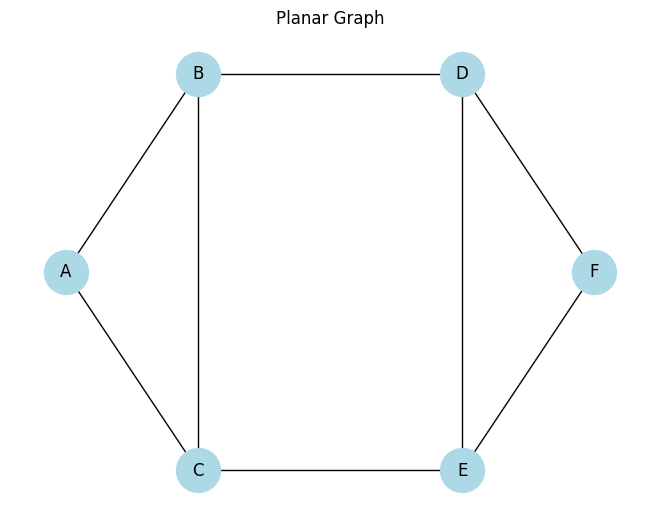

Is the graph planar? True


In [32]:
#(a).Planar Graph Analysis a) Visualize the graph using Python and determine whether the graph is planar
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# Add edges
G.add_edges_from([
    ("A","B"), ("A","C"), ("B","C"),
    ("B","D"), ("C","E"),
    ("D","E"), ("D","F"), ("E","F")
])

# Position of nodes (Planar drawing)
pos = {
    "A": (0,1),
    "B": (1,2),
    "C": (1,0),
    "D": (3,2),
    "E": (3,0),
    "F": (4,1)
}

# Draw graph
nx.draw(G, pos,
        with_labels=True,
        node_color="lightblue",
        node_size=1000)

plt.title("Planar Graph")
plt.show()

# Check planarity
print("Is the graph planar?", nx.check_planarity(G)[0])

In [34]:
#(b) Use Euler’s planar graph theorem ( V - E + F = 2 ) to verify whether the graph satisfies the planar condition.
# Formula:r=e-v+2
V=6
E=8
F = E - V + 2                              # Euler formula( V - E + F = 2 ) # Face and region same


print("F =", F)
print("Valid:", V - E + F == 2)

F = 4
Valid: True


In [36]:
# (c) If the graph is planar, compute the number of regions in a planar embedding.
V = 6
E = 8

F = E - V + 2

print("Vertices (V):", V)
print("Edges (E):", E)
print("Regions (F):", F)

Vertices (V): 6
Edges (E): 8
Regions (F): 4


In [38]:
# (d) Write a Python function that checks whether the inequality ( E <= 3V - 6 ) holds and interpret the result.
def check_planar(V, E):
    if E <= 3 * V - 6:
        print("The inequality is satisfied.")
        print("The graph satisfies the necessary condition for a planar graph.")
    else:
        print("The inequality is not satisfied.")
        print("The graph is not planar.")

# Given graph
V = 6
E = 8

check_planar(V, E)

The inequality is satisfied.
The graph satisfies the necessary condition for a planar graph.


Graph Distance Measures
a) Compute the shortest path lengths between all pairs of vertices.
b) For each vertex, calculate its eccentricity.
c) Determine the diameter and radius of the graph.
d) Identify the center(s) of the graph.
e) Identify the peripheral of the graph.
f) Color the center and peripheral of the graph with two different colors


In [41]:
#(a) Graph Distance Measures a) Compute the shortest path lengths between all pairs of vertices.
import networkx as nx
import matplotlib.pyplot as plt
G = nx.Graph()

edges = [
    ('A','B'), ('A','C'), ('B','C'),
    ('B','D'), ('C','E'),
    ('D','E'), ('D','F'), ('E','F')
]

G.add_edges_from(edges)

all_shortest = dict(nx.all_pairs_shortest_path_length(G))
print("Shortest Path Lengths:\n", all_shortest)

Shortest Path Lengths:
 {'A': {'A': 0, 'B': 1, 'C': 1, 'D': 2, 'E': 2, 'F': 3}, 'B': {'B': 0, 'A': 1, 'C': 1, 'D': 1, 'E': 2, 'F': 2}, 'C': {'C': 0, 'A': 1, 'B': 1, 'E': 1, 'D': 2, 'F': 2}, 'D': {'D': 0, 'B': 1, 'E': 1, 'F': 1, 'A': 2, 'C': 2}, 'E': {'E': 0, 'C': 1, 'D': 1, 'F': 1, 'A': 2, 'B': 2}, 'F': {'F': 0, 'D': 1, 'E': 1, 'B': 2, 'C': 2, 'A': 3}}


In [42]:
# (b).For each vertex, calculate its eccentricity
ecc = nx.eccentricity(G)
print("Eccentricity: ", ecc)

Eccentricity:  {'A': 3, 'B': 2, 'C': 2, 'D': 2, 'E': 2, 'F': 3}


In [43]:
#(c) Determine the diameter and radius of the graph.
diameter = nx.diameter(G)
radius = nx.radius(G)

print("Diameter:", diameter)
print("Radius:", radius)

Diameter: 3
Radius: 2


In [44]:
#(d) Identify the center(s) of the graph.
center = nx.center(G)
print("Center:", center)

Center: ['B', 'C', 'D', 'E']


In [45]:
#(e) Identify the peripheral of the graph.
peripheral = nx.periphery(G)
print("Peripheral:", peripheral)

Peripheral: ['A', 'F']


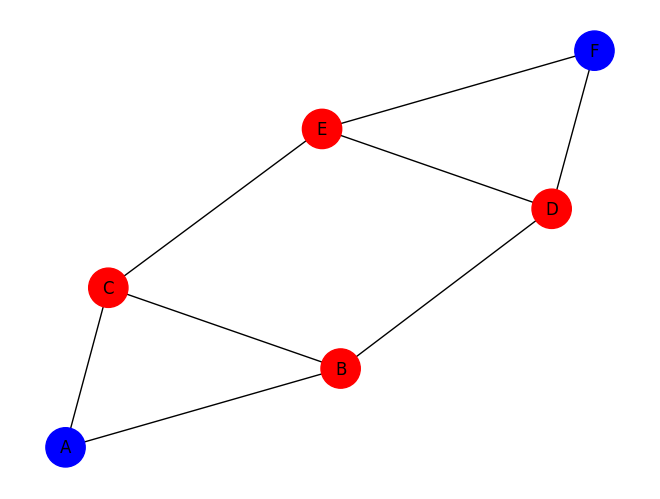

In [46]:
#(f) Color the center and peripheral of the graph with two different color
import matplotlib.pyplot as plt
color_map = []

for node in G.nodes():
    if node in center:
        color_map.append("red")
    elif node in peripheral:
        color_map.append("blue")
    else:
        color_map.append("lightgray")

nx.draw(G, with_labels=True, node_color=color_map, node_size=800)
plt.show()

In [47]:
import networkx as nx

# Create graph
G = nx.Graph()

G.add_edges_from([
    ("A","B"), ("A","C"), ("B","C"),
    ("B","D"), ("C","E"),
    ("D","E"), ("D","F"), ("E","F")
])

# Original graph
print("Original Graph")
print("Diameter =", nx.diameter(G))
print("Radius =", nx.radius(G))

# Add one extra edge
G.add_edge("A", "F")

# Updated graph
print("\nAfter Adding Edge (A,F)")
print("Diameter =", nx.diameter(G))
print("Radius =", nx.radius(G))

Original Graph
Diameter = 3
Radius = 2

After Adding Edge (A,F)
Diameter = 2
Radius = 2
